In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.io as pio


In [53]:
df1 = pd.read_csv("1948 - 1986.csv")
df2 = pd.read_csv("1987 - 2022.csv")
df3 = pd.read_csv("2023.csv")

In [54]:
df2.head() #Son todos distintos asi que usar solo el de 1987 hasta 2022 para las tecnicas

,Title,Seasons,Episodes,Country,Premiere Year,Final Year,Original Channel,Technique
0,¡Mucha Lucha!,3,52,United States,2002,2005,Kids' WB,Flash
1,10+2,1,52,Spain,1994,1994,"Televisió de Catalunya, KiKa",Traditional
2,100% Wolf: Legend of the Moonstone,2,26,Australia,2020,Present,ABC Me,CGI
3,1001 Nights,2,52,Canada,2011,2012,Teletoon,Flash
4,101 Dalmatian Street,1,40,"United Kingdom, Canada",2019,2020,"Disney Channel, Disney+",Toon Boom Harmony


In [55]:
cols = ["Title", "Premiere Year", "Final Year"] 
df1_sel = df1[cols]
df2_sel = df2[cols]
df4 = pd.concat([df1_sel, df2_sel], ignore_index=True)
df4.head()

,Title,Premiere Year,Final Year
0,001/7 Oyayubi Tom,1967,1967
1,3000 Leagues in Search of Mother,1976,1976
2,A kockásfülű nyúl,1977,1979
3,A Rubovian Legend,1955,1955
4,Ace o Nerae!,1973,1974


In [56]:
#Para duracion de serie (runtime, no episodios) por pais, unir premiere y final excepto cuando final es presente
df4["Final Year"] = df4["Final Year"].astype(str)
df4["Premiere Year"] = df4["Premiere Year"].astype(str)
def compute_duration(row):
    if row["Final Year"].lower() == "present":
        return "Running"
    else:
        return int(row["Final Year"]) - int(row["Premiere Year"]) + 1

In [57]:
df4["duration"] = df4.apply(compute_duration, axis=1)
df4 = df4[df4["duration"] != "Running"]
df4 = df4[df4["duration"] >= 0] #Hay mucho dato malo que tiene serie que terminan antes de empezar

In [58]:
df4.head()

,Title,Premiere Year,Final Year,duration
0,001/7 Oyayubi Tom,1967,1967,1
1,3000 Leagues in Search of Mother,1976,1976,1
2,A kockásfülű nyúl,1977,1979,3
3,A Rubovian Legend,1955,1955,1
4,Ace o Nerae!,1973,1974,2


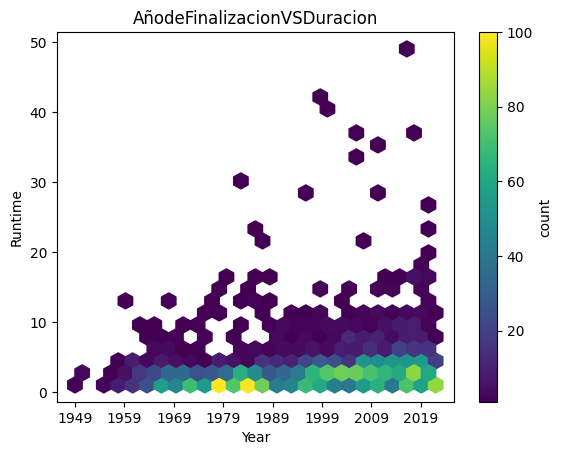

In [59]:
#Probando Graficos...
df4["Final Year"] = pd.to_numeric(df4["Final Year"], errors="coerce")
df4 = df4.dropna(subset=["Final Year"])
df4["Final Year"] = df4["Final Year"].astype(int)
plt.hexbin(df4["Final Year"], df4["duration"], gridsize=25, mincnt = 1)
plt.colorbar(label="count")
plt.xlabel("Year")
plt.ylabel("Runtime")
plt.xticks(
    ticks=np.arange(df4["Final Year"].min(), df4["Final Year"].max() + 1, 10)
)
plt.title("AñodeFinalizacionVSDuracion")
plt.savefig("añoVSduracion5.png")
plt.show()

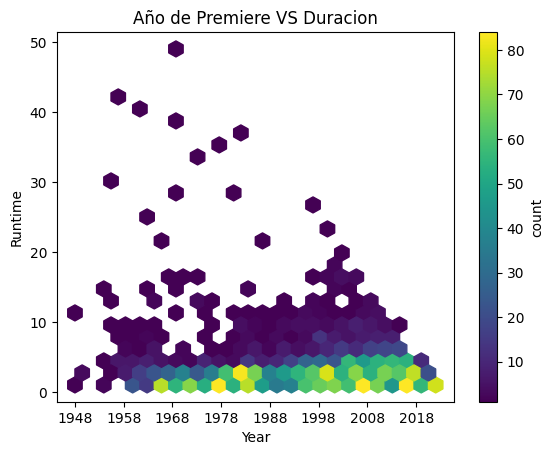

In [60]:
#Probando Graficos...
df4["Premiere Year"] = pd.to_numeric(df4["Premiere Year"], errors="coerce")
df4 = df4.dropna(subset=["Premiere Year"])
df4["Premiere Year"] = df4["Premiere Year"].astype(int)
plt.hexbin(df4["Premiere Year"], df4["duration"], gridsize=25, mincnt = 1)
plt.colorbar(label="count")
plt.xlabel("Year")
plt.ylabel("Runtime")
plt.xticks(
    ticks=np.arange(df4["Premiere Year"].min(), df4["Premiere Year"].max() + 1, 10)
)
plt.title("Año de Premiere VS Duracion")
plt.savefig("añoVSduracion6.png")
plt.show()

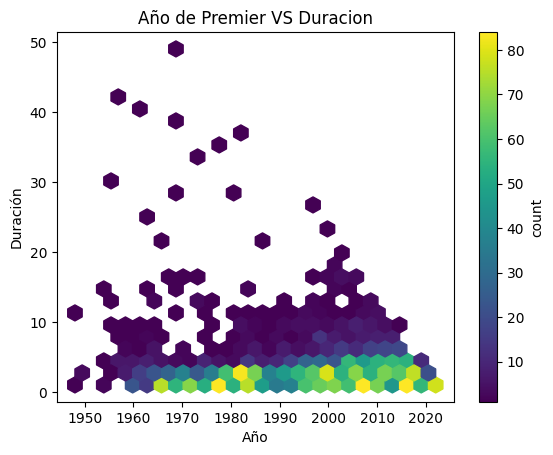

In [61]:
plt.hexbin(df4["Premiere Year"], df4["duration"], gridsize=25, mincnt = 1)
plt.colorbar(label="count")
plt.xlabel("Año")
plt.ylabel("Duración")
plt.title("Año de Premier VS Duracion")
plt.savefig("añoVSduracion3.png")
plt.show()

In [63]:
#joyplot(df4, by="Premiere Year", column="duration")
#plt.show()
#No logre hacer funcionar el joyplot


In [64]:
df2["Technique"] = df2["Technique"].str.split(",")
df2 = df2.explode("Technique")
df2["Technique"] = df2["Technique"].str.split("/")
df2 = df2.explode("Technique")
df2["Technique"] = df2["Technique"].str.strip()
df2 = df2[~df2["Technique"].str.contains(r"\(|\)", regex=True, na=False)]


In [65]:
df2["Technique"] = df2["Technique"].replace({
    "ToonBoom Harmony": "Toon Boom Harmony",
    "Toon Boom[1]": "Toon Boom Harmony",
    "later Flash": "Flash",
    "Toon Boom": "Toon Boom Harmony",
    "Toom Boom": "Toon Boom Harmony",
    "Toom Boon": "Toon Boom Harmony",

    "Stop Motion": "Stop Motion",
    "Stop-Motion": "Stop Motion",
    "Stop-motion": "Stop Motion",
    "Stop motion": "Stop Motion",
    
    "Live Action": "Live Action",
    "Live action": "Live Action",
    "Live-Action": "Live Action",
    "Live-action": "Live Action",
    "Live action and Flash": "Live Action"
})# Esto debiera ser un regex pero lo pense muy tarde....

In [67]:
df2["duration"] = df2.apply(compute_duration, axis=1)
df2 = df2[df2["duration"] != "Running"]
df2 = df2[df2["duration"] >= 0] #Hay mucho dato malo que tiene serie que terminan antes de empezar

In [68]:
pio.renderers.default = "browser"
avg = df2.groupby("Technique")["duration"].mean().reset_index()
fig = px.treemap(
    avg,
    path=["Technique"],
    values="duration",
    color="duration"
)

fig.show()

In [69]:
avg.head()

,Technique,duration
0,Animation,5.0
1,CGI,3.196388
2,Claymation,7.0
3,Flash,3.09542
4,Live Action,3.87234


In [70]:
print(avg)

           Technique  duration
0          Animation       5.0
1                CGI  3.196388
2         Claymation       7.0
3              Flash   3.09542
4        Live Action   3.87234
5          Rotoscope       1.0
6        Stop Motion  3.423913
7         Syncro-Vox       3.0
8  Toon Boom Harmony      2.75
9        Traditional  2.991254


In [71]:
tech_counts = df2["Technique"].value_counts().reset_index()
tech_counts.columns = ["Technique", "count"]

In [74]:
fig = px.treemap(
    tech_counts,
    path=["Technique"],
    values="count",
    color="count"
)
fig.update_traces(
    textfont_size=25
)

fig.show()